# Nichesphere revision material (PIC-seq)


## Libraries and functions

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 
import warnings
warnings.filterwarnings("ignore")

In [2]:
######## Niches heatmaps

In [3]:
d={0: ['Fibro', 'Baso', 'MonoPro', 'InfiltMac'],
 1: ['Ly6ClowMac', 'ResMac', 'DC'],
 2: ['OsteoCAR', 'TCells', 'BCells', 'Spp1+Mac', 'Ery', 'MK', 'EC'],
 3: ['Neut1', 'Neut2']}

niche_names=['1_FibInfiltMac', '2_Macs', '3_Core', '4_Neut']
niches_original=d

In [4]:
df_original = pd.DataFrame(niches_original.items(), columns=['Niche', 'Cell_type']).explode('Cell_type').reset_index(drop=True)
df_original.index=df_original.Cell_type

In [5]:
d={0: ['Baso', 'DC', 'Fibro', 'ResMac', 'Neut2'],
 1: ['Spp1+Mac', 'MK', 'Ery', 'TCells', 'OsteoCAR'],
 2: ['Ly6ClowMac', 'EC', 'InfiltMac'],
 3: ['BCells', 'MonoPro', 'Neut1']}

niche_names=['1_Neut_ResMac_Baso_DC', '2_FibCore', '3_InfiltMacs_EC', '4_BCells_MonoPro_Neut']
niches_BGdist_per_CTpair=d

In [6]:
df_BGdist_per_CTpair = pd.DataFrame(niches_BGdist_per_CTpair.items(), columns=['Niche', 'Cell_type']).explode('Cell_type').reset_index(drop=True)
df_BGdist_per_CTpair.index=df_BGdist_per_CTpair.Cell_type

In [7]:
d={0: ['Baso', 'DC', 'Neut2', 'ResMac'],
 1: ['MK', 'Spp1+Mac', 'Ery', 'TCells', 'OsteoCAR'],
 2: ['Ly6ClowMac', 'EC', 'InfiltMac'],
 3: ['BCells', 'MonoPro', 'Fibro', 'Neut1']}

niche_names=['1_Neut_ResMac_Baso_DC', '2_FibCore', '3_Macs_EC', '4_BCells_Fibro']
niches_final=d

In [8]:
df_final = pd.DataFrame(niches_final.items(), columns=['Niche', 'Cell_type']).explode('Cell_type').reset_index(drop=True)
df_final.index=df_final.Cell_type

In [9]:
#Niches colors
cmap = plt.colormaps['tab10'].resampled(10)
clist=[mcolors.rgb2hex(cmap(i)[:3]) for i in [9]]

cmap = plt.colormaps['Set1'].resampled(9)
clist=clist+[mcolors.rgb2hex(cmap(i)[:3]) for i in [7,2,3]]

In [10]:
### comparison specific niche color lists
clist_original=['#17becf', '#f781bf', '#4daf4a', '#984ea3']
clist_BGdist_per_CTpair=['#FDBCB4', '#4C9A2A', '#C8A2C8', '#4A6984']
clist_final=['#FF8C00', '#32CD32',  '#E64B35', '#FFD700']

In [11]:
## make colormaps based on color lists
cmap_original=mcolors.ListedColormap(clist_original)
cmap_BGdist_per_CTpair=mcolors.ListedColormap(clist_BGdist_per_CTpair)
cmap_final=mcolors.ListedColormap(clist_final)

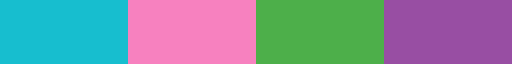

In [12]:
cmap_original

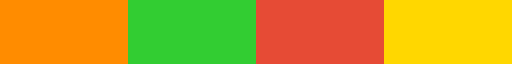

In [13]:
cmap_final

In [14]:
## double heatmap for niche mapping visualization
## cell type x niche number data frame
df=pd.concat([df_original['Niche'], df_final['Niche']], axis=1)
df.columns=['Original niches', 'Niches']

In [15]:
df=df.sort_values(['Original niches', 'Niches'])

In [16]:
sns.set(font_scale=1.5)
plt.rcParams['axes.facecolor'] = "None"

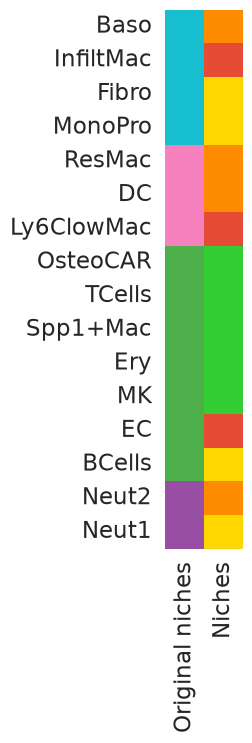

In [17]:
cm = [cmap_original, cmap_final]
f, axs = plt.subplots(1, df.columns.size, gridspec_kw={'wspace': 0}, figsize=(1,7))
for i, (s, a, c) in enumerate(zip(df.columns, axs, cm)):
    sns.heatmap(np.array([df[s].values]).T, yticklabels=df.index, xticklabels=[s], annot=False, fmt='.2f', ax=a, cmap=c, cbar=False)
    a.set_xticklabels([s], rotation=90)
    if i>0:
        a.yaxis.set_ticks([])

f.savefig('../figures/revision/FR3/FR3B.pdf', bbox_inches="tight")

In [18]:
df=pd.concat([df_original['Niche'], df_BGdist_per_CTpair['Niche']], axis=1)
df.columns=['Original niches', 'Niches']

In [19]:
df=df.sort_values(['Original niches', 'Niches'])

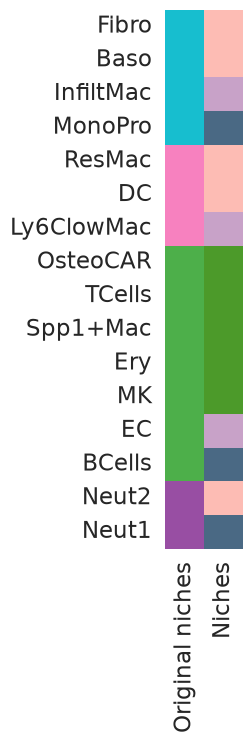

In [20]:
cm = [cmap_original, cmap_BGdist_per_CTpair]
f, axs = plt.subplots(1, df.columns.size, gridspec_kw={'wspace': 0}, figsize=(1,7))
for i, (s, a, c) in enumerate(zip(df.columns, axs, cm)):
    sns.heatmap(np.array([df[s].values]).T, yticklabels=df.index, xticklabels=[s], annot=False, fmt='.2f', ax=a, cmap=c, cbar=False)
    a.set_xticklabels([s], rotation=90)
    if i>0:
        a.yaxis.set_ticks([])

#f.savefig('../figures/revision/original_BGdist_per_CTpair_niches.pdf', bbox_inches="tight")